# How the concept of *Astronomer* changed over time

This notebook traces the **continuous evolution** of co-occupations attached to people identified as *astronomers* in the database.
Rather than collapsing history into three coarse periods, we slice time into 100-year bins and show, for each bin, the share of contemporary astronomers who also held each of the most common secondary occupations.

The resulting figure is a time-series heatmap: the x-axis is calendar time, the y-axis is the top co-occupations, and the colour intensity is the within-period share. A marginal line above the heatmap shows how many astronomers populate each period.

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.duckdb"

# Time binning
BIN_WIDTH = 100          # years per period
YEAR_MIN = -500          # include classical antiquity onward
YEAR_MAX = 1950          # data ends cleanly here
MIN_N_PER_BIN = 15       # bins with < this many astronomers are dropped (too noisy)
TOP_N_OCCUPATIONS = 14   # rows of the heatmap

# Variants of "astronomer" itself: excluded from the co-occupation set
ASTRONOMER_VARIANTS = {
    "astronomer", "amateur astronomer", "radio astronomer",
    "archaeoastronomer", "astronomer royal",
}

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (12, 7)
DPI = 200
FONT_TITLE = 14
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette
COLOR_PRIMARY = "#2171b5"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

## 1. Load astronomer records

We pull every individual whose `occupations_en` field contains *astronomer* and join with the impact-date table, which already encodes the period of their cultural activity.

In [ ]:
import duckdb
import polars as pl

conn = duckdb.connect(DB_PATH, read_only=True)

query = """
    SELECT i.wikidata_id,
           i.occupations_en,
           d.floruit_period_start
    FROM individuals i
    JOIN individuals_floruit_period d ON i.wikidata_id = d.wikidata_id
    WHERE i.occupations_en LIKE '%astronomer%'
      AND d.floruit_period_start IS NOT NULL
"""
df_raw = conn.execute(query).pl()
conn.close()

print(f"Loaded {df_raw.height:,} astronomer records")
assert df_raw['wikidata_id'].n_unique() == df_raw.height, 'Expected one row per astronomer'
df_raw.head()

## 2. Parse co-occupations and assign each astronomer to a time bin

Each astronomer gets:
* a **period**: the 100-year bucket containing their `impact_year`, restricted to `YEAR_MIN`..`YEAR_MAX`;
* a **co-occupations list**: their other occupations, with all variants of *astronomer* removed.

In [ ]:
def split_occs(s):
    return [o.strip() for o in s.split(';') if o.strip()]

def co_occupations(occs):
    return [o for o in occs if o.lower() not in ASTRONOMER_VARIANTS]

df = df_raw.filter(
    (pl.col('floruit_period_start') >= YEAR_MIN) & (pl.col('floruit_period_start') <= YEAR_MAX)
)
n_dropped = df_raw.height - df.height
print(f'After year filter [{YEAR_MIN}, {YEAR_MAX}]: {df.height:,} rows ({n_dropped} dropped)')

# Period = left edge of the 100-year bin, e.g. floruit_period_start=1623 -> 1600
df = df.with_columns(
    ((pl.col('floruit_period_start') // BIN_WIDTH) * BIN_WIDTH).cast(pl.Int64).alias('period'),
    pl.col('occupations_en')
        .map_elements(lambda s: co_occupations(split_occs(s)), return_dtype=pl.List(pl.Utf8))
        .alias('co_occs'),
)
df = df.with_columns(pl.col('co_occs').list.len().alias('n_co_occs'))

df.sample(5, seed=SEED)

## 3. Build the full set of 100-year periods

We keep **every** 100-year bin in `[YEAR_MIN, YEAR_MAX]` so the time axis is continuous and ticks appear at every period. Bins with fewer than `MIN_N_PER_BIN` astronomers are flagged as *sparse* — their shares are masked (shown as gray) in the figure rather than dropped from the axis.

In [ ]:
# Full continuous list of 100-year periods (left edges) within [YEAR_MIN, YEAR_MAX]
all_periods = list(range(YEAR_MIN, YEAR_MAX, BIN_WIDTH))

period_counts = (
    pl.DataFrame({'period': all_periods})
    .join(
        df.group_by('period').agg(pl.len().alias('n_astronomers')),
        on='period', how='left',
    )
    .with_columns(
        pl.col('n_astronomers').fill_null(0),
    )
    .with_columns(
        (pl.col('n_astronomers') < MIN_N_PER_BIN).alias('sparse'),
    )
    .sort('period')
)

n_sparse = int(period_counts['sparse'].sum())
print(f'Total 100-year periods in range: {len(all_periods)}')
print(f'  with >= {MIN_N_PER_BIN} astronomers (shown): {len(all_periods) - n_sparse}')
print(f'  sparse (masked in heatmap):                  {n_sparse}')

period_counts

## 4. Select the top co-occupations

Across the **non-sparse** periods we count how often each non-astronomer occupation appears, and keep the `TOP_N_OCCUPATIONS` most frequent. These are the rows of the heatmap.

In [ ]:
from collections import Counter

non_sparse_periods = period_counts.filter(~pl.col('sparse'))['period'].to_list()
df_dense = df.filter(pl.col('period').is_in(non_sparse_periods))

global_counts = Counter()
for occs in df_dense['co_occs'].to_list():
    global_counts.update(set(occs))   # one count per astronomer

top_occs = [o for o, _ in global_counts.most_common(TOP_N_OCCUPATIONS)]
top_df = pl.DataFrame({
    'occupation':    top_occs,
    'n_astronomers': [global_counts[o] for o in top_occs],
    'share':         [global_counts[o] / df_dense.height for o in top_occs],
})
top_df

## 5. Build the period × occupation share matrix

For each 100-year bin and each top occupation we compute, **independently per period**:

$$\text{share}_{p,o} = \frac{\#\{\text{astronomers in } p \text{ also } o\}}{\#\{\text{astronomers in } p\}}$$

Sparse periods are filled with `NaN` so the time axis stays continuous. Each column therefore answers: *of the astronomers active during this 100-year window, what fraction also held occupation o?*

In [ ]:
# Build the period × occupation share matrix in polars, then expose it as a
# pandas DataFrame for the matplotlib heatmap (which uses .values/.idxmax/.iloc).
import pandas as pd  # plotting boundary only

per_period_total = (
    df.group_by('period').agg(pl.len().alias('n_period'))
)

# explode + dedupe per (period, astronomer, occupation) so an astronomer counts once
exploded = (
    df.with_columns(
        pl.col('co_occs').list.unique().alias('co_occs_uniq')
    )
    .explode('co_occs_uniq')
    .drop_nulls('co_occs_uniq')
    .filter(pl.col('co_occs_uniq').is_in(top_occs))
)

per_cell = (
    exploded.group_by(['period', 'co_occs_uniq']).agg(pl.len().alias('n'))
    .join(per_period_total, on='period', how='left')
    .with_columns((pl.col('n') / pl.col('n_period')).alias('share'))
)

# Pivot to wide: rows = periods, cols = top_occs
wide = per_cell.pivot(values='share', index='period', on='co_occs_uniq')
# Convert to pandas for downstream heatmap code that uses matrix.values / .idxmax / .iloc
wide_pd = wide.to_pandas().set_index('period').reindex(all_periods)

# Mask sparse periods to NaN
sparse_set = set(period_counts.filter(pl.col('sparse'))['period'].to_list())
for p in sparse_set:
    wide_pd.loc[p, :] = np.nan

# Ensure every top_occ column is present
for o in top_occs:
    if o not in wide_pd.columns:
        wide_pd[o] = np.nan
matrix = wide_pd[top_occs].T  # rows = occupations, cols = periods

n_per_period = pd.Series(
    period_counts.sort('period')['n_astronomers'].to_list(),
    index=all_periods, name='n_astronomers', dtype=int,
)

# Order rows so that occupations peaking earliest appear on top (NaN-safe)
row_peak = matrix.idxmax(axis=1, skipna=True)
matrix = matrix.loc[row_peak.sort_values().index]

vals = matrix.values
assert np.nanmin(vals) >= 0 and np.nanmax(vals) <= 1
print('Share matrix shape:', matrix.shape, ' (rows = top co-occupations, cols = 100-year periods)')
matrix.round(2)

## 6. Detect dense blocks on the heatmap

To highlight the visible "regimes" of the astronomer concept (e.g. the medieval astrologer block, the modern physicist block at the bottom-right), we threshold the share matrix and find connected rectangular regions of high-share cells. Each block is then outlined on the figure.

In [7]:
from scipy.ndimage import label, find_objects, generate_binary_structure

# Block-detection parameters (co-occupation shares only — astronomer variants are
# already excluded via ASTRONOMER_VARIANTS).
STRICT_THRESHOLD = 0.20    # high-share medieval polymath regimes
SOFT_THRESHOLD   = 0.08    # low-share modern academic regime
MIN_BLOCK_CELLS  = 3
BLOCK_MIN_PERIODS = 2

# 4-connectivity: don't let diagonals merge unrelated regimes.
struct4 = generate_binary_structure(2, 1)

def _detect_blocks(mat: pd.DataFrame, threshold: float, row_filter: np.ndarray | None = None):
    arr = mat.fillna(0).values.copy()
    if row_filter is not None:
        arr[~row_filter, :] = 0          # zero-out rows that aren't candidates
    mask = (arr >= threshold)
    lbl, _ = label(mask, structure=struct4)
    out = []
    for k, sl in enumerate(find_objects(lbl), start=1):
        rows, cols = sl
        cells = (lbl[sl] == k).sum()
        n_periods = cols.stop - cols.start
        if cells < MIN_BLOCK_CELLS or n_periods < BLOCK_MIN_PERIODS:
            continue
        sub = mat.iloc[rows, cols].where(lbl[sl] == k)
        out.append({
            "row_start":    rows.start,
            "row_stop":     rows.stop,
            "col_start":    cols.start,
            "col_stop":     cols.stop,
            "n_cells":      int(cells),
            "n_periods":    n_periods,
            "period_range": (mat.columns[cols.start], mat.columns[cols.stop - 1] + BIN_WIDTH),
            "occupations":  list(mat.index[rows.start:rows.stop]),
            "mean_share":   float(np.nanmean(sub.values)),
        })
    return out

# Pass 1 — strict threshold over all rows: finds the medieval / mathematician regimes.
strict_blocks = _detect_blocks(matrix, STRICT_THRESHOLD)
for b in strict_blocks:
    b["kind"] = "strict"

# Pass 2 — soft threshold restricted to rows whose peak is in the modern era (>= 1500),
# so the bottom-right "modern academic" regime gets its own cluster despite lower shares.
peak_period = matrix.idxmax(axis=1, skipna=True)
modern_mask = (peak_period.values >= 1500)
soft_blocks = _detect_blocks(matrix, SOFT_THRESHOLD, row_filter=modern_mask)
for b in soft_blocks:
    b["kind"] = "soft"

blocks = strict_blocks + soft_blocks
print(f"Detected {len(strict_blocks)} strict block(s) at >= {STRICT_THRESHOLD:.0%}, "
      f"and {len(soft_blocks)} soft block(s) at >= {SOFT_THRESHOLD:.0%} (modern rows only)")
pd.DataFrame(blocks)[["kind", "period_range", "occupations", "n_cells", "mean_share"]]

Detected 3 strict block(s) at >= 20%, and 3 soft block(s) at >= 8% (modern rows only)


,kind,period_range,occupations,n_cells,mean_share
0,strict,"(700, 1900)",[mathematician],12,0.457791
1,strict,"(1000, 1400)","[writer, philosopher]",7,0.252695
2,strict,"(700, 1600)","[astrologer, physician]",11,0.362527
3,soft,"(1400, 2000)","[university teacher, cartographer]",8,0.149825
4,soft,"(900, 1200)","[cartographer, physicist]",4,0.095833
5,soft,"(1600, 2000)",[physicist],4,0.121920


### Figure 12: Co-occupations of astronomers across time

Top panel: number of astronomers per 100-year period.

Bottom panel: **share of astronomers within each 100-year window** who also held each of the top co-occupations — every column is normalised independently against the size of *its own century*. The colour scale is square-rooted (`PowerNorm(γ=0.5)`) so that low-share cells in the modern era remain readable; the underlying data is unchanged.

Sparse periods (< `MIN_N_PER_BIN` astronomers) are shown in light gray. Two kinds of cluster outline are drawn in orange:

* **solid rectangles** — strict regime, share ≥ 20 % (medieval polymath block, persistent mathematician spine);
* **dashed rectangle** — soft regime restricted to rows whose peak is in the modern era (≥ 1500), share ≥ 8 % (university teacher / cartographer / physicist / astrophysicist — the modern academic profile).

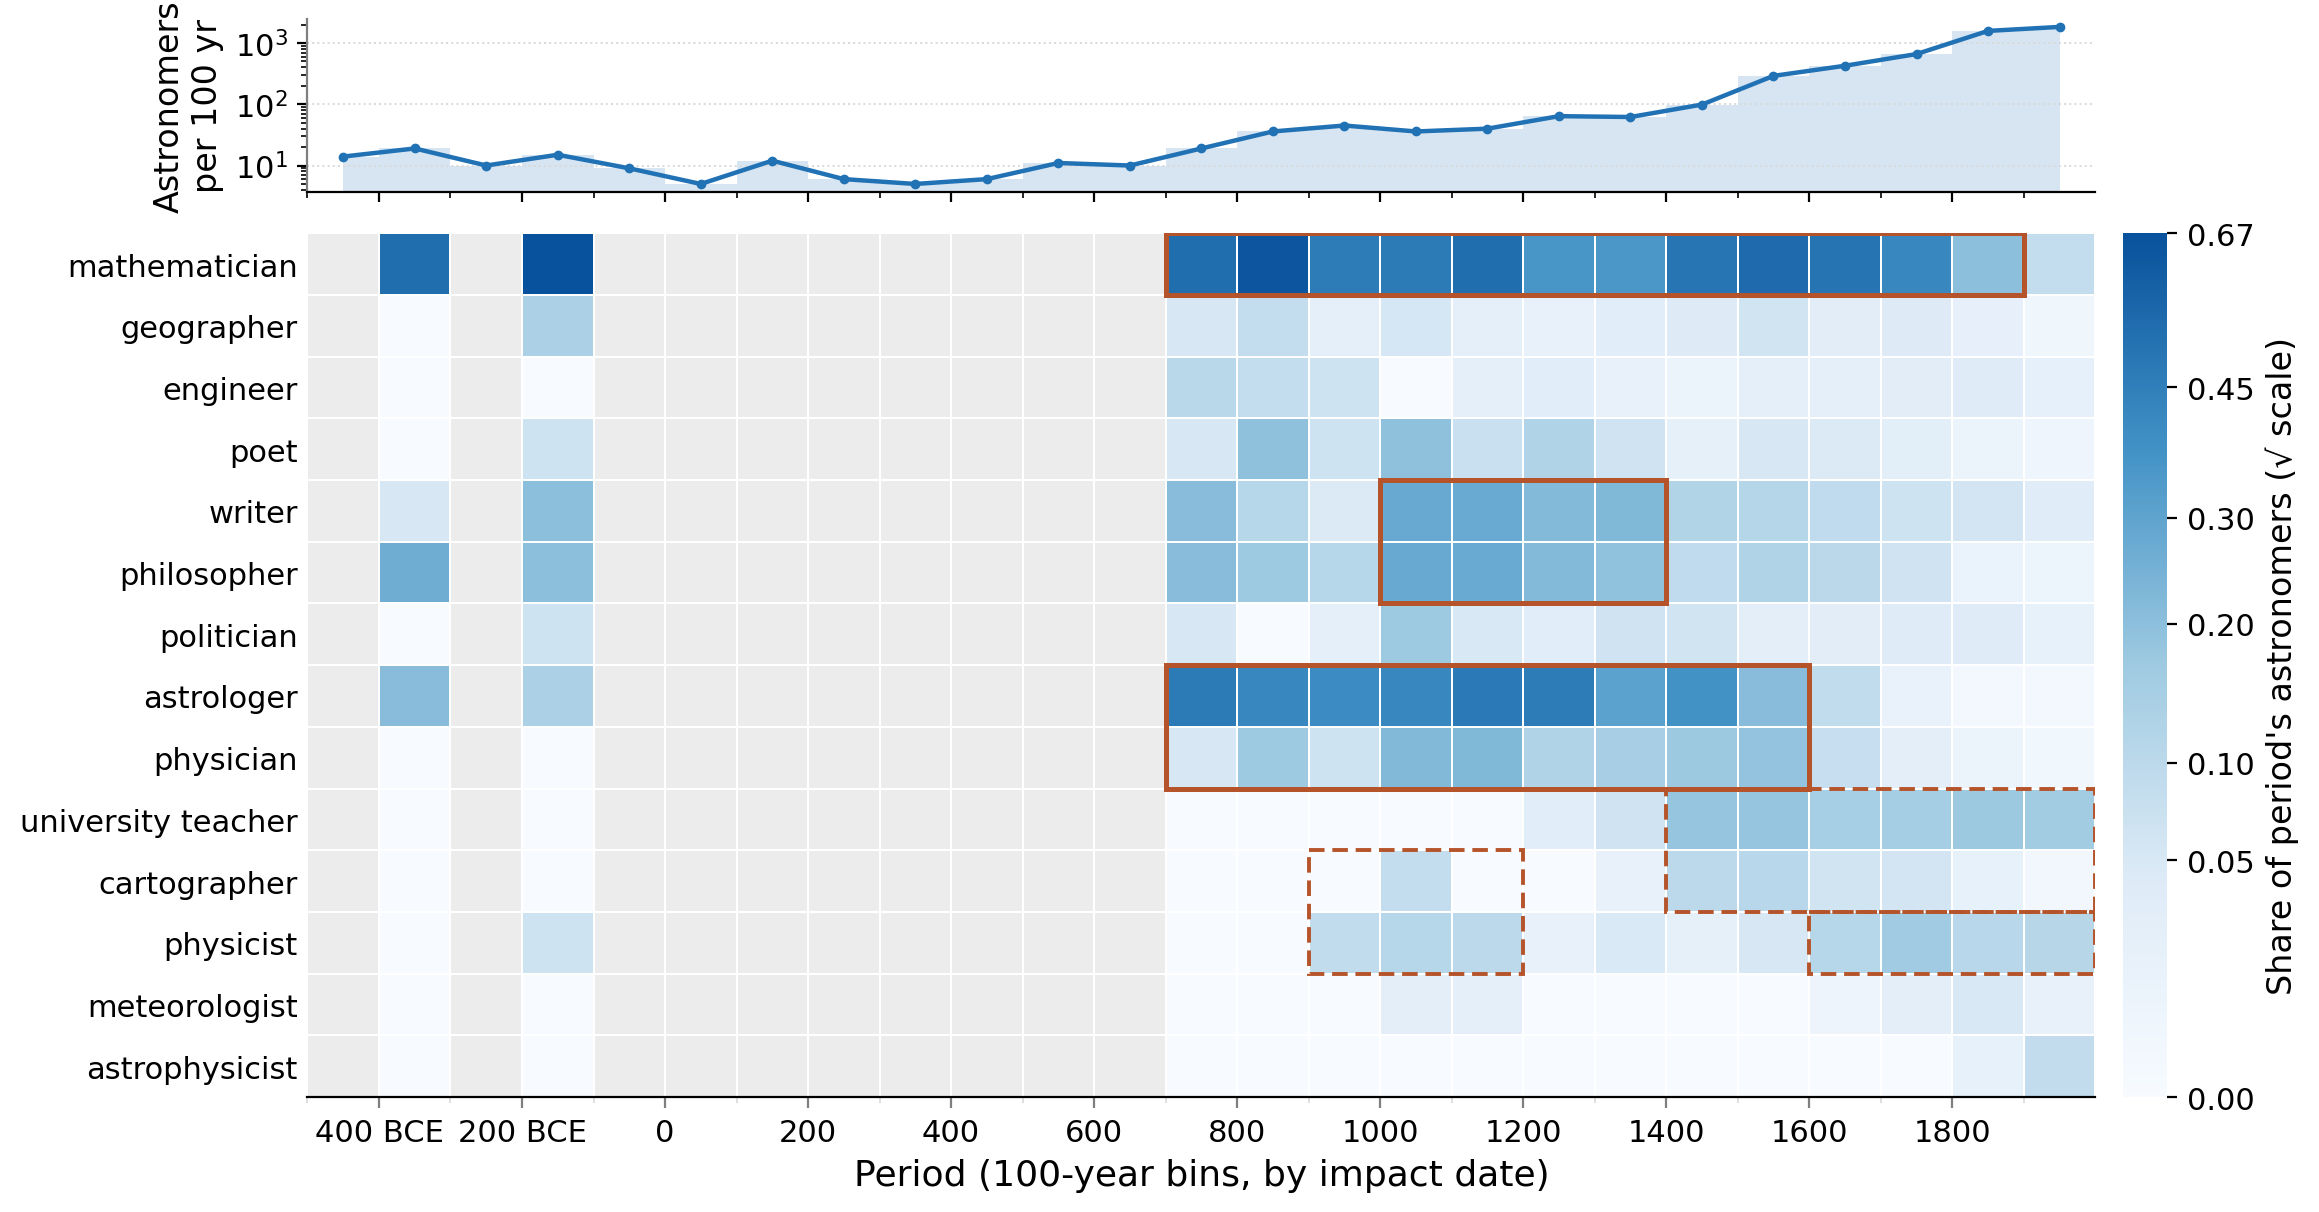

In [8]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.patches import Rectangle

# Light, single-hue cmap: very pale blue -> deep blue. NaN cells render in light gray.
cmap = LinearSegmentedColormap.from_list(
    "soft_blue", ["#f7fbff", "#deebf7", "#9ecae1", "#4292c6", "#08519c"]
)
cmap.set_bad(color="#ececec")

# Sqrt colour scale (gamma=0.5): boosts the visibility of low-share cells in the
# modern era without altering the underlying per-century normalisation of the data.
vmax = float(np.nanmax(matrix.values))
norm = PowerNorm(gamma=0.5, vmin=0, vmax=vmax)

fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
gs = GridSpec(2, 2, height_ratios=[1, 5], width_ratios=[40, 1],
              hspace=0.08, wspace=0.03, figure=fig)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_cbar = fig.add_subplot(gs[1, 1])

x = np.array(all_periods)
x_centers = x + BIN_WIDTH / 2
edges_x = np.append(x, x[-1] + BIN_WIDTH)

# --- Top: count of astronomers per period ---
counts = n_per_period.reindex(all_periods).values.astype(float)
counts_plot = np.where(counts > 0, counts, np.nan)
ax_top.fill_between(x_centers, 0, np.where(np.isnan(counts_plot), 0, counts_plot),
                    step="mid", color=COLOR_PRIMARY, alpha=0.18, linewidth=0)
ax_top.plot(x_centers, counts_plot, color=COLOR_PRIMARY, linewidth=1.6, marker="o", markersize=2.5)
ax_top.set_ylabel("Astronomers\nper 100 yr", fontsize=FONT_LABEL - 1)
ax_top.tick_params(labelbottom=False)
ax_top.set_yscale("log")
ax_top.spines["left"].set_color(COLOR_NEUTRAL)
ax_top.grid(axis="y", linestyle=":", color=COLOR_LIGHT, linewidth=0.7)

# --- Main: heatmap (sqrt scale to make the modern era visible) ---
data = np.ma.masked_invalid(matrix.values)
edges_y = np.arange(len(matrix.index) + 1)
mesh = ax_main.pcolormesh(
    edges_x, edges_y, data,
    cmap=cmap, norm=norm,
    shading="flat", edgecolors="white", linewidth=0.6,
)
ax_main.set_yticks(np.arange(len(matrix.index)) + 0.5)
ax_main.set_yticklabels(matrix.index)
ax_main.invert_yaxis()
ax_main.set_xlabel("Period (100-year bins, by impact date)")
ax_main.set_xlim(edges_x[0], edges_x[-1])

# --- Cluster outlines: solid orange = strict regime, dashed = soft modern regime ---
STYLE = {
    "strict": dict(edgecolor="#b5542a", linewidth=1.8, linestyle="-"),
    "soft":   dict(edgecolor="#b5542a", linewidth=1.4, linestyle=(0, (4, 2))),
}
for b in blocks:
    x0 = matrix.columns[b["col_start"]]
    x1 = matrix.columns[b["col_stop"] - 1] + BIN_WIDTH
    y0, y1 = b["row_start"], b["row_stop"]
    ax_main.add_patch(Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        fill=False, joinstyle="miter", zorder=5,
        **STYLE[b["kind"]],
    ))

# Period tick labels every 200 years across the full range.
tick_step = 200
ticks = np.arange(int(np.ceil(YEAR_MIN / tick_step) * tick_step), YEAR_MAX + 1, tick_step)
ax_main.set_xticks(ticks)
ax_main.set_xticklabels([f"{t}" if t >= 0 else f"{abs(t)} BCE" for t in ticks])
ax_main.tick_params(axis="x", which="major", length=4, color=COLOR_NEUTRAL)
ax_main.set_xticks(x, minor=True)
ax_main.tick_params(axis="x", which="minor", length=2, color=COLOR_LIGHT)

for spine in ("top", "right", "left"):
    ax_main.spines[spine].set_visible(False)
ax_main.tick_params(axis="y", length=0)

cbar = fig.colorbar(mesh, cax=ax_cbar)
cbar.set_label("Share of period's astronomers (√ scale)", fontsize=FONT_LABEL - 1)
cbar.outline.set_visible(False)
# Tick labels show actual share values (0, 0.1, 0.2, …) on the sqrt-warped axis.
cbar_ticks = [0.0, 0.05, 0.10, 0.20, 0.30, 0.45, vmax]
cbar.set_ticks([t for t in cbar_ticks if t <= vmax])
cbar.set_ticklabels([f"{t:.2f}" for t in cbar_ticks if t <= vmax])

plt.show()

### Reading the figure

* The top panel makes the asymmetric coverage explicit: astronomer records are sparse before 1500 and explode after 1700.
* In the heatmap, **astrologer** dominates the medieval and early-modern bins and fades after ~1700, the historical moment when astronomy and astrology are institutionally separated.
* **Mathematician** and **philosopher** carry most of the early-modern weight; from the 19th century onward the dense rows shift to **physicist**, **university teacher**, **writer** — the modern academic profile.
* The diagonal-like pattern of the row ordering visualises the gradual conceptual drift from a polymath/astrology-adjacent figure to a specialised research scientist.